In [1]:
import cv2
import numpy as np
import glob
import yaml
import pickle
import os
from ultralytics import YOLO
import tkinter as tk
from tkinter import messagebox
import matplotlib.pyplot as plt
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
with open("config.yaml", "r") as file:
    config = yaml.safe_load(file)["image_processing"]
with open("artefact/homography_matrix.pkl", "rb") as file:
    homography_matrix = pickle.load(file)

In [18]:
frame_files = sorted(glob.glob(config["input_frames"]))
image_path = frame_files[1]
output_path = config["output_file"]
output_frames = config["output_frames"] + image_path[-9:-4]

In [19]:
# Load the image
image = cv2.imread(image_path)

# Load YOLOv8 model
model = YOLO("yolov8m.pt")  # Using the smallest YOLOv8 model (change to yolov8m.pt for better accuracy)

# Run YOLOv8 detection
results = model(image)

# Extract detections
detections = results[0].boxes.xyxy.cpu().numpy()  # Bounding boxes (xmin, ymin, xmax, ymax)
class_ids = results[0].boxes.cls.cpu().numpy()  # Class IDs

# Define YOLO class labels
yolo_classes = model.names  # Get class names from YOLO model

# Filter only players (class "person") and the ball (class "sports ball")
players = []
ball = None

for i, class_id in enumerate(class_ids):
    class_name = yolo_classes[int(class_id)]
    xmin, ymin, xmax, ymax = detections[i]

    if class_name == "person":  # Detect players
        xmin, ymin, xmax, ymax = detections[i]
        px, py = int((xmin + xmax) / 2), int(ymax)  # Bottom-center of the bounding box
        players.append((px, py))  # Store coordinates with bbox

    elif class_name == "ball":  # Detect ball
        ball = (int((xmin + xmax) / 2), int((ymin + ymax) / 2))




0: 352x640 28 persons, 252.3ms
Speed: 3.0ms preprocess, 252.3ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)


In [20]:
# Dictionary to store team assignments
player_teams = {}
ball_position = None  # Placeholder for the ball position
team_colors = {}  # Store selected colors for teams

# Function to handle color selection
jersey_colors = {}

def select_color(event, x, y, flags, param):
    global jersey_colors, image, selecting_team
    if event == cv2.EVENT_LBUTTONDOWN:
        jersey_colors[selecting_team] = image[y, x].tolist()  # Store BGR color
        print(f"{selecting_team} team jersey color selected: {jersey_colors[selecting_team]}")

# Function to handle player selection
def assign_team(event, x, y, flags, param):
    global player_teams, players, current_team
    if event == cv2.EVENT_LBUTTONDOWN:  # Left-click to select a player
        closest_player = None
        min_dist = float("inf")
        
        # Find the closest detected player
        for px, py in players:
            dist = np.sqrt((x - px) ** 2 + (y - py) ** 2)
            if dist < min_dist:
                min_dist = dist
                closest_player = (px, py)
        
        if closest_player and closest_player[:2] not in player_teams:
            player_teams[closest_player[:2]] = current_team
            print(f"Player at {closest_player[:2]} assigned to Team {current_team}")

In [21]:
# Step 1: Select jersey colors for each team
cv2.namedWindow("Select Jersey Color", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Select Jersey Color", select_color)
cv2.waitKey(1)

root = tk.Tk()
root.withdraw()

selecting_team = "A"
messagebox.showinfo("Jersey Color Selection", f"Click on the jersey of Team {selecting_team}")
while True:
    temp_img = image.copy()
    cv2.imshow("Select Jersey Color", temp_img)
    key = cv2.waitKey(1) & 0xFF
    if key == ord("\r"):  # Press Enter to confirm color selection
        break

cv2.waitKey(1)

selecting_team = "D"
messagebox.showinfo("Jersey Color Selection", f"Click on the jersey of Team {selecting_team}")
while True:
    temp_img = image.copy()
    cv2.imshow("Select Jersey Color", temp_img)
    key = cv2.waitKey(1) & 0xFF
    if key == ord("\r"):  # Press Enter to confirm color selection
        break
cv2.destroyWindow("Select Jersey Color")

A team jersey color selected: [144, 64, 53]
D team jersey color selected: [250, 249, 251]


In [ ]:
# Step 2: Assign Team A (Attacking)
cv2.namedWindow("Assign Teams", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Assign Teams", assign_team)

root = tk.Tk()
root.withdraw()
messagebox.showinfo("Team Selection", "Click on all players going left (Team R), then press ENTER.")

current_team = "R"  # Assigning attacking players
while True:
    temp_img = image.copy()
    for px, py in players:
        color = (255, 0, 0) if (px, py) in player_teams else (0, 255, 255)
        cv2.circle(temp_img, (px, py), 10, color, -1)
    cv2.imshow("Assign Teams", temp_img)
    key = cv2.waitKey(1) & 0xFF
    if key == ord("\r"):  # Press Enter to move to next step
        break

# Step 3: Assign Team D (Defending)
messagebox.showinfo("Team Selection", "Click on all players going right (Team L), then press ENTER.")

current_team = "L"
while True:
    temp_img = image.copy()
    for px, py in players:
        color = (0, 0, 255) if (px, py) in player_teams else (0, 255, 255)
        cv2.circle(temp_img, (px, py), 10, color, -1)
    cv2.imshow("Assign Teams", temp_img)
    key = cv2.waitKey(1) & 0xFF
    if key == ord("\r"):  # Press Enter to finish player assignment
        break
cv2.destroyWindow("Assign Teams")

Player at (188, 844) assigned to Team A
Player at (126, 871) assigned to Team A
Player at (615, 790) assigned to Team A
Player at (882, 712) assigned to Team A
Player at (960, 694) assigned to Team A
Player at (983, 663) assigned to Team A
Player at (1368, 674) assigned to Team A
Player at (1431, 605) assigned to Team A
Player at (7, 673) assigned to Team D
Player at (41, 872) assigned to Team D
Player at (370, 778) assigned to Team D
Player at (528, 740) assigned to Team D
Player at (748, 704) assigned to Team D
Player at (791, 663) assigned to Team D
Player at (819, 644) assigned to Team D
Player at (861, 597) assigned to Team D
Player at (964, 541) assigned to Team D
Player at (666, 484) assigned to Team D


In [23]:
# Step 4: Select Ball Manually
cv2.namedWindow("Select Ball", cv2.WINDOW_NORMAL)

def select_ball(event, x, y, flags, param):
    global ball_position
    if event == cv2.EVENT_LBUTTONDOWN:
        ball_position = (x, y)
        print(f"Ball selected at: {ball_position}")

cv2.setMouseCallback("Select Ball", select_ball)
messagebox.showinfo("Ball Selection", "Click on the ball, then press Enter when finished.")

while True:
    temp_img = image.copy()
    if ball_position:
        cv2.circle(temp_img, ball_position, 10, (0, 165, 255), -1)  # Orange for ball
    cv2.imshow("Select Ball", temp_img)
    key = cv2.waitKey(1) & 0xFF
    if key == ord("\r"):  # Press Enter to exit
        break
cv2.destroyAllWindows()

Ball selected at: (956, 645)


In [24]:
# Print final results
print("Final Team Assignments:", player_teams)
if ball_position:
    print(f"Final Ball Position (Pixels): {ball_position}")
else:
    print("No ball selected.")

Final Team Assignments: {(188, 844): 'A', (126, 871): 'A', (615, 790): 'A', (882, 712): 'A', (960, 694): 'A', (983, 663): 'A', (1368, 674): 'A', (1431, 605): 'A', (7, 673): 'D', (41, 872): 'D', (370, 778): 'D', (528, 740): 'D', (748, 704): 'D', (791, 663): 'D', (819, 644): 'D', (861, 597): 'D', (964, 541): 'D', (666, 484): 'D'}
Final Ball Position (Pixels): (956, 645)


In [25]:
def pixel_to_real(px, py, H):
    pixel_coord = np.array([[px, py, 1]], dtype=np.float32).T
    real_coord = np.dot(H, pixel_coord)
    real_coord /= real_coord[2]  # Normalize
    return real_coord[0][0], real_coord[1][0]  # X, Y in meters

In [26]:
# Convert player positions to real-world meters
players_real_coords = {pixel_to_real(px, py, homography_matrix): team for (px, py), team in player_teams.items()}

# Convert ball position if detected
if ball_position:
    ball_real_x, ball_real_y = pixel_to_real(ball_position[0], ball_position[1], homography_matrix)
else:
    ball_real_x, ball_real_y = None, None

print("Player Positions (Real-World):", players_real_coords)
print("Ball Position (Real-World):", (ball_real_x, ball_real_y) if ball_position else "Not detected")


Player Positions (Real-World): {(19.21948436540039, 4.929163884909931): 'A', (19.2489421971233, 3.0393231159235756): 'A', (24.240912801059505, 10.777370614247232): 'A', (26.32772967212222, 18.64971197373085): 'A', (27.18988810467272, 20.823028113553683): 'A', (26.55413253580594, 24.104611355554024): 'A', (34.541609974192916, 25.47671449486559): 'A', (34.089799152426814, 34.10895939396714): 'A', (7.6891904129415645, 16.68810404449172): 'D', (17.993426440717446, 2.557432161399403): 'D', (19.657548086546534, 10.273909936769348): 'D', (20.898875013963654, 14.10068203650174): 'D', (23.52463125803915, 18.548418890717606): 'D', (22.709039646590462, 22.82926104671088): 'D', (22.462182421341662, 25.053473527046044): 'D', (21.177692298790063, 30.96377723934065): 'D', (20.65464087592605, 39.78281974396803): 'D', (8.95749340694907, 47.16594098390322): 'D'}
Ball Position (Real-World): (25.32588115383363, 25.87923952779791)


In [27]:
import pandas as pd

df = pd.DataFrame([k + (v,) for k, v in players_real_coords.items()], columns=['x_field', 'y_field', 'team'])
df['object'] = 'person'
df['color'] = df["team"].map(jersey_colors)
df['frame'] = output_frames

df.loc[len(df)] = [ball_real_x, ball_real_y, None, "ball", [255, 165, 0], output_frames]

df.to_csv(output_path, index=False, mode='a', header=False)

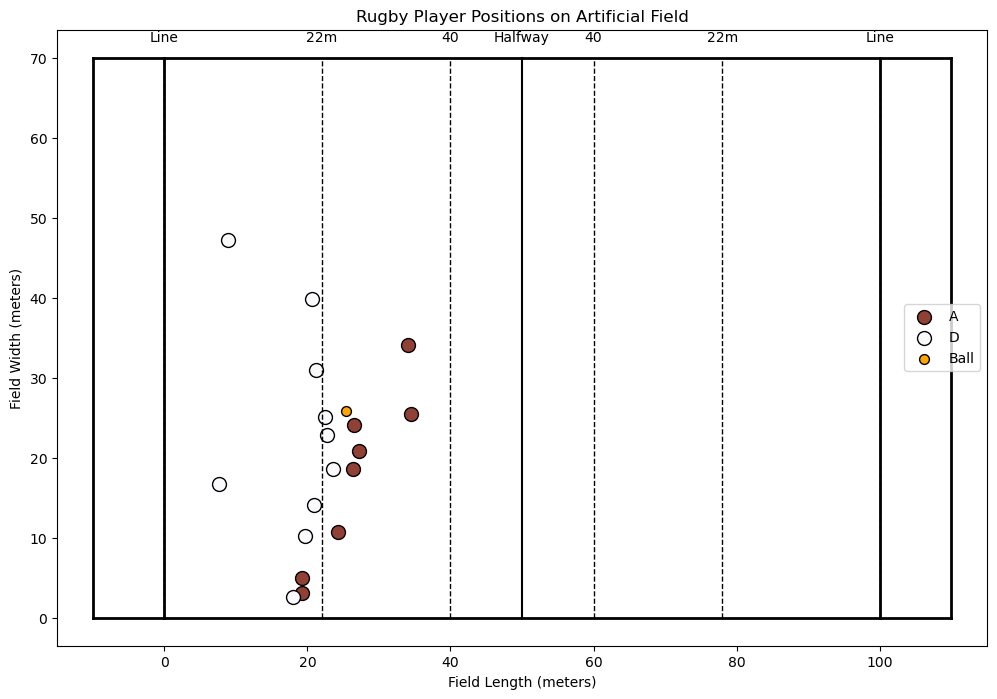

In [28]:
# Rugby field dimensions
FIELD_LENGTH = 100  # Full field length (goal line to goal line)
FIELD_WIDTH = 70    # Full field width (sideline to sideline)

# Create a figure
fig, ax = plt.subplots(figsize=(12, 8))

ax.set_xlim(-15, FIELD_LENGTH + 15)

# Draw field boundaries
ax.plot([-10, -10], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Left sideline
ax.plot([0, 0], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Left sideline
ax.plot([FIELD_LENGTH, FIELD_LENGTH], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Right sideline
ax.plot([FIELD_LENGTH+10, FIELD_LENGTH+10], [0, FIELD_WIDTH], 'k-', linewidth=2)  # Right sideline
ax.plot([-10, FIELD_LENGTH+10], [0, 0], 'k-', linewidth=2)  # Bottom (goal line)
ax.plot([-10, FIELD_LENGTH+10], [FIELD_WIDTH, FIELD_WIDTH], 'k-', linewidth=2)  # Top (goal line)

# Draw major field lines
ax.plot([0, 0], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
ax.plot([22, 22], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
ax.plot([40, 40], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
ax.plot([50, 50], [0, FIELD_WIDTH], 'k-', linewidth=1.5)  # Halfway line
ax.plot([60, 60], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (left)
ax.plot([78, 78], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (right)
ax.plot([100, 100], [0, FIELD_WIDTH], 'k--', linewidth=1)  # 22m line (right)

# Label key lines
ax.text(0, FIELD_WIDTH + 2, "Line", ha='center', fontsize=10, color='black')
ax.text(22, FIELD_WIDTH + 2, "22m", ha='center', fontsize=10, color='black')
ax.text(40, FIELD_WIDTH + 2, "40", ha='center', fontsize=10, color='black')
ax.text(50, FIELD_WIDTH + 2, "Halfway", ha='center', fontsize=10, color='black')
ax.text(60, FIELD_WIDTH + 2, "40", ha='center', fontsize=10, color='black')
ax.text(78, FIELD_WIDTH + 2, "22m", ha='center', fontsize=10, color='black')
ax.text(100, FIELD_WIDTH + 2, "Line", ha='center', fontsize=10, color='black')

for (real_x, real_y) in players_real_coords:
    team_name = players_real_coords[(real_x, real_y)]
    team_color = np.array(jersey_colors[team_name]) / 255
    ax.scatter(real_x, real_y, c=[team_color], s=100, edgecolors='black', label=team_name)
    player_plotted = True

# Plot ball if detected
if ball_position is not None:
    ax.scatter(ball_real_x, ball_real_y, c='orange', s=50, marker='o', edgecolors='black', label="Ball")

# Fix legend by removing duplicates
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Remove duplicates
ax.legend(unique_labels.values(), unique_labels.keys())

# Titles and labels
ax.set_xlabel("Field Length (meters)")
ax.set_ylabel("Field Width (meters)")
ax.set_title("Rugby Player Positions on Artificial Field")

# Ensure the plot is displayed
plt.savefig(output_frames)
plt.show()
